# Intra-Beam Scattering
Calculation of IBS for each lattice

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from cpymad.madx import Madx

In [2]:
m = Madx()
m.call('IBS.madx')


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Windows)     +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.01.27 16:10:05      +
  ++++++++++++++++++++++++++++++++++++++++++++

enter Twiss module
  
iteration:   1 error:   1.492384E-19 deltap:   0.000000E+00
orbit:   1.595745E-26 -6.825954E-26 -6.985233E-25 -2.898027E-26  1.500542E-16  1.747510E-23
++++++ warning: TWCLORB:  Longitudinal plane might be unstable. Try change lag with 0.5. More information with the debug flag on.                                                                                                                                                   

++++++ table: summ

            length             orbit5               alfa            gammatr 
            503.04    -1.50054193e-16      0.01991393184         7.08633194 

                q1                dq1            betxmax              dxmax 
       9.440

In [3]:
# file from MADX IBS module
file_path = 'IBS_over_lattice.dat'
const = 2.085047E-05  # unique for each beam and energy

In [4]:
try:
    # read file, skip several first rows
    df = pd.read_csv(file_path, skiprows=8, sep=r'\s+', header=None)
    
    # --- Columns ---
    df.columns = [
        'NAME', 'S', 'DELS', 'TLI', 'TXI', 'TYI', 
        'BETX', 'ALFX', 'DX', 'DPX', 
        'BETY', 'ALFY', 'DY', 'DPY'
    ] 
    
    print("Done.")
    print(df.head())
    print(f"\nTotal rows: {len(df)}")

except FileNotFoundError:
    print(f"Error, file'{file_path}' not found.")
    exit()
except Exception as e:
    print(f"Error during reading the file: {e}")
    exit()

Done.
    NAME       S   DELS       TLI       TXI       TYI        BETX       ALFX  \
0  C_SPD  2.6250  5.250 -0.051508  0.029392  0.031581   23.686159  -4.397815   
1   HQFF  5.2500  0.000 -0.245633  0.270477  0.274631   46.774688  -8.790284   
2  QFF6W  5.7250  0.950 -0.264039  0.676323  0.120502   68.663781 -25.953974   
3   HQFF  6.2000  0.000 -0.268679  1.084375  0.032614   90.552875 -43.117664   
4    OO1  6.3575  0.315 -0.266288  1.411485 -0.034729  105.154077 -46.353021   

         DX       DPX       BETY       ALFY        DY       DPY  
0 -0.010344 -0.004287  23.692578  -4.399388 -0.042095 -0.001584  
1 -0.021596 -0.004287  46.789367  -8.805510 -0.046253 -0.001584  
2 -0.025936 -0.009431  45.832424   0.873182 -0.042603  0.007432  
3 -0.030275 -0.014575  44.875482  10.551875 -0.038954  0.016448  
4 -0.032571 -0.014575  41.675842  10.157587 -0.036363  0.016448  

Total rows: 1280


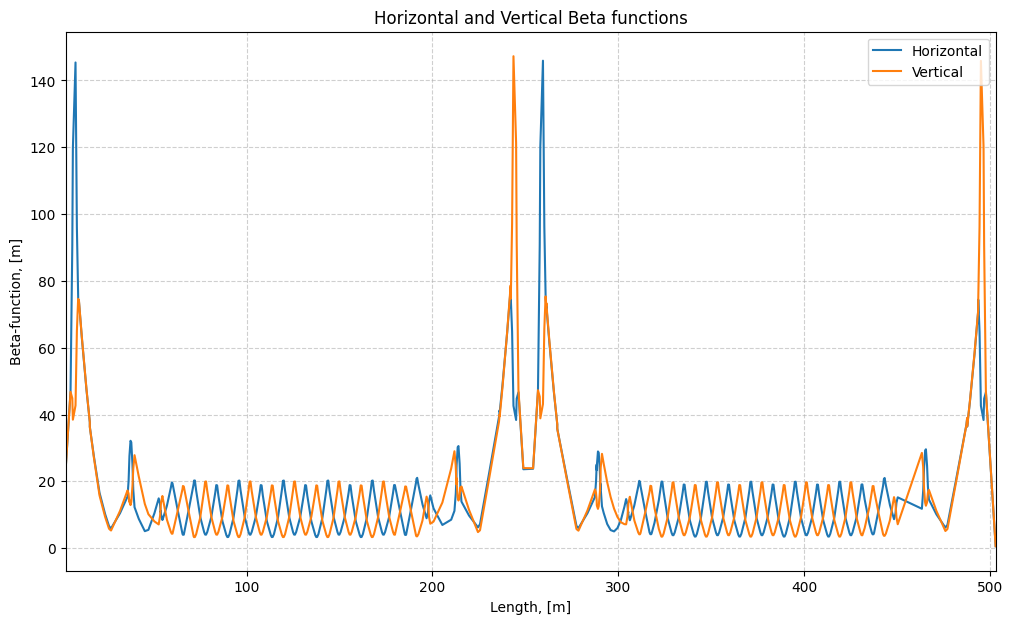

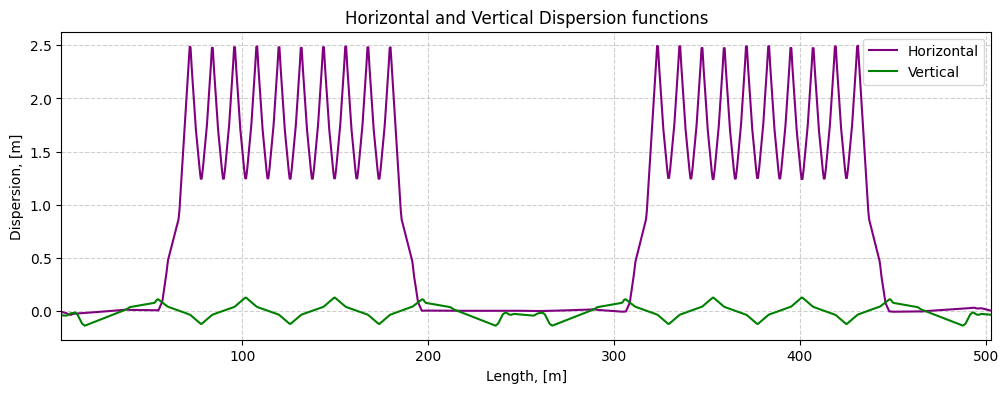

In [5]:
# --- Vizualization of Beta and Dispersion function over the ring ---

plt.figure(figsize=(12, 7))

plt.plot(df['S'], df['BETX'], label='Horizontal', marker='', linestyle='-')
plt.plot(df['S'], df['BETY'], label='Vertical', marker='', linestyle='-')

plt.title('Horizontal and Vertical Beta functions')
plt.xlabel('Length, [m]')
plt.ylabel('Beta-function, [m]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(min(df['S']), max(df['S'])) 
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df['S'], df['DX'], label='Horizontal', color='purple')
plt.plot(df['S'], df['DY'], label='Vertical', color='green')
plt.title('Horizontal and Vertical Dispersion functions')
plt.xlabel('Length, [m]')
plt.ylabel('Dispersion, [m]')
plt.xlim(min(df['S']), max(df['S']))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

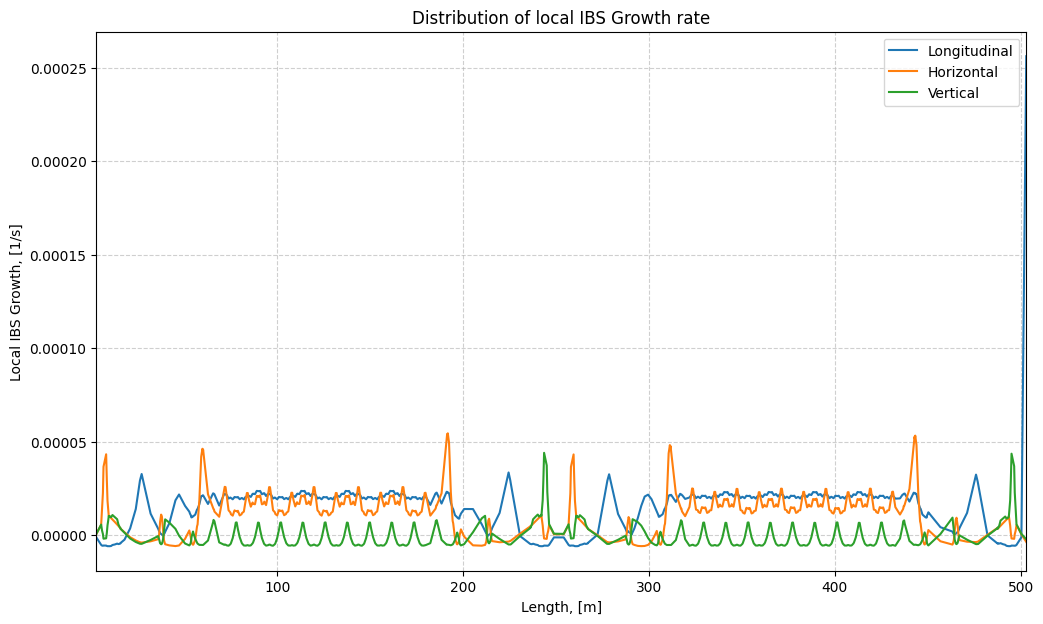

In [6]:
# --- Vizualization for TLI, TXI и TYI over the length S ---

plt.figure(figsize=(12, 7))

# Plot for each parameter
plt.plot(df['S'], const * df['TLI'], label='Longitudinal', marker='', linestyle='-', markersize=4)
plt.plot(df['S'], const * df['TXI'], label='Horizontal', marker='', linestyle='-', markersize=4)
plt.plot(df['S'], const * df['TYI'], label='Vertical', marker='', linestyle='-', markersize=4)

plt.title('Distribution of local IBS Growth rate')
plt.xlabel('Length, [m]')
plt.ylabel('Local IBS Growth, [1/s]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(min(df['S']), max(df['S'])) # Устанавливаем пределы по оси X для наглядности
plt.legend() # Отображает легенду с названиями параметров

# --- Отображение графика ---
plt.show()

In [7]:
# Total length of accelerator
total_length = df['DELS'].sum()

# Check total length not zero
if total_length == 0:
    print("Error, check: 'DELS'.")
    exit()

print(f"\nОбщая длина ускорителя (S_total): {total_length:.4f} м")


Общая длина ускорителя (S_total): 503.0400 м


In [8]:
# Calculation for integral value of 1/T
# B&M intergal * DELS for each element
def calculate_integral_average(column_name):
    rate = df[column_name]
    weighted_sum = const*((rate*df['DELS']).sum())/total_length # multiply by const!
    return weighted_sum

In [9]:
# Time calculation as 1 / rate
avg_tl = 1/calculate_integral_average('TLI')
avg_tx = 1/calculate_integral_average('TXI')
avg_ty = 1/calculate_integral_average('TYI')

In [10]:
print("\n--- (Weighted) average lifetimes (sec): ---")
print(f"Total length: {total_length:.4f} м")
print("-" * 30)
print(f"Longitudinal: {avg_tl:.8e}")
print(f"Horizontal: {avg_tx:.8e}")
print(f"Vertical: {avg_ty:.8e}")


--- (Weighted) average lifetimes (sec): ---
Total length: 503.0400 м
------------------------------
Longitudinal: 7.41154771e+04
Horizontal: 1.08209586e+05
Vertical: -1.47184059e+06


In [11]:
# For averave value calculation
def ring_avg(column_name):
    return (df[column_name] * df['DELS']).sum() / total_length

avg_betx = ring_avg('BETX')
avg_bety = ring_avg('BETY')
avg_dx   = ring_avg('DX')
avg_dy   = ring_avg('DY')
avg_alfx = ring_avg('ALFX')
avg_alfy = ring_avg('ALFY')
avg_dpx  = ring_avg('DPX')
avg_dpy  = ring_avg('DPY')

# for inverse (1/beta)
avg_inv_betx = ( (1.0 / df['BETX']) * df['DELS'] ).sum() / total_length
avg_inv_bety = ( (1.0 / df['BETY']) * df['DELS'] ).sum() / total_length

# print
print(f"Ring average values (m):")
print(f"betx   =  {avg_betx:.5E}    bety   =  {avg_bety:.5E}    Dx  =  {avg_dx:.5E}    Dy  =  {avg_dy:.5E}")
print(f"alfx   =  {avg_alfx:.5E}    alfy   =  {avg_alfy:.5E}    Dpx =  {avg_dpx:.5E}   Dpy =  {avg_dpy:.5E}")
print(f"1/betx =  {avg_inv_betx:.5E}    1/bety =  {avg_inv_bety:.5E}")

Ring average values (m):
betx   =  1.66474E+01    bety   =  1.67718E+01    Dx  =  8.87977E-01    Dy  =  -1.06192E-02
alfx   =  6.36807E-03    alfy   =  -1.09514E-02    Dpx =  2.99042E-06   Dpy =  2.68607E-06
1/betx =  9.75929E-02    1/bety =  9.75676E-02


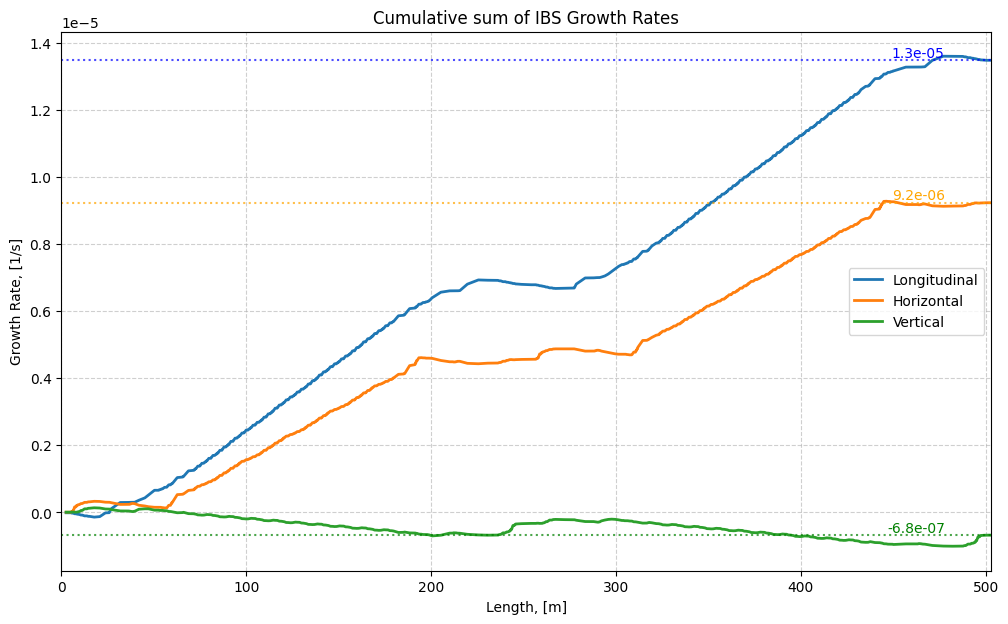


--- (Weighted) average lifetimes (sec): ---
Longitudanl: 7.411548e+04
Horizontal: 1.082096e+05
Vertical: -1.471841e+06


In [12]:
# IBS Time at each element 
df['IBS_rate_l'] = (const * (df['TLI'] * df['DELS']) / total_length)
df['IBS_rate_h'] = (const * (df['TXI'] * df['DELS']) / total_length) 
df['IBS_rate_v'] = (const * (df['TYI'] * df['DELS']) / total_length) 

#Make an additional column - Cumulative sum of IBS time 
df['IBS_cumulative_rate_l'] = df['IBS_rate_l'].cumsum()
df['IBS_cumulative_rate_h'] = df['IBS_rate_h'].cumsum()
df['IBS_cumulative_rate_v'] = df['IBS_rate_v'].cumsum()

# Plot over length
plt.figure(figsize=(12, 7))

plt.plot(df['S'], df['IBS_cumulative_rate_l'], label='Longitudinal', linewidth=2)
plt.plot(df['S'], df['IBS_cumulative_rate_h'], label='Horizontal', linewidth=2)
plt.plot(df['S'], df['IBS_cumulative_rate_v'], label='Vertical', linewidth=2)

plt.title('Cumulative sum of IBS Growth Rates')
plt.xlabel('Length, [m]')
plt.ylabel('Growth Rate, [1/s]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, total_length) # От 0 до конца кольца
plt.legend()

# Add sum lines
plt.axhline(y=df['IBS_cumulative_rate_l'].iloc[-1], color='blue', linestyle=':', alpha=0.7)
plt.axhline(y=df['IBS_cumulative_rate_h'].iloc[-1], color='orange', linestyle=':', alpha=0.7)
plt.axhline(y=df['IBS_cumulative_rate_v'].iloc[-1], color='green', linestyle=':', alpha=0.7)

text_x_position = total_length * 0.95 
plt.text(text_x_position, df['IBS_cumulative_rate_l'].iloc[-1], f'{df['IBS_cumulative_rate_l'].iloc[-1]:.1e}', color='blue', va='bottom', ha='right')
plt.text(text_x_position, df['IBS_cumulative_rate_h'].iloc[-1], f'{df['IBS_cumulative_rate_h'].iloc[-1]:.1e}', color='orange', va='bottom', ha='right')
plt.text(text_x_position, df['IBS_cumulative_rate_v'].iloc[-1], f'{df['IBS_cumulative_rate_v'].iloc[-1]:.1e}', color='green', va='bottom', ha='right')

plt.show()

# Print final values
print("\n--- (Weighted) average lifetimes (sec): ---")
print(f"Longitudanl: {1/df['IBS_cumulative_rate_l'].iloc[-1]:.6e}")
print(f"Horizontal: {1/df['IBS_cumulative_rate_h'].iloc[-1]:.6e}")
print(f"Vertical: {1/df['IBS_cumulative_rate_v'].iloc[-1]:.6e}")